This notebook is to extract polygons from survey plans images

In [1]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 100.6 MB/s eta 0:00:0000:0100:01


In [2]:
%%capture
!uv pip install -q git+https://github.com/huggingface/transformers.git
!uv pip install segmentation-models-pytorch pytorch-lightning
!uv pip install -q vllm
!uv pip install -q qwen-vl-utils

In [3]:
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
import numpy as np
import cv2
import torch
from qwen_vl_utils import process_vision_info
from transformers import AutoProcessor
from vllm import LLM, SamplingParams
import pytorch_lightning as pl
from albumentations.pytorch import ToTensorV2
import albumentations as A
import segmentation_models_pytorch as smp
from dataclasses import dataclass
from typing import List, Tuple, Optional, Sequence
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


# Set multiprocessing method
os.environ['VLLM_WORKER_MULTIPROC_METHOD'] = 'spawn'

2025-12-22 04:03:17.533964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766376197.759779      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766376197.824393      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766376198.378126      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766376198.378160      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766376198.378163      55 computation_placer.cc:177] computation placer alr

In [4]:
!mkdir -p /kaggle/working/images
!cp -r /kaggle/input/segtest/survey_plans/* /kaggle/working/images/

In [5]:
df = pd.read_csv("/kaggle/input/segtest/test_full.csv")

df["ID"] = (
    df["image_path"]
    .str.split("_").str[-1]   # take part after underscore
    .str.split(".").str[0]    # remove file extension
)

# Move ID column to the leftmost position
cols = ["ID"]
df = df[cols]

df.to_csv("/kaggle/working/test_full.csv", index=False)


In [6]:
DATA_PATH = "/kaggle/input/segtest"
EXTRACT_PATH = "/kaggle/working/images"

import pandas as pd

def load_datasets():
    """Load and return train, test, and sample submission datasets"""
    test_df = pd.read_csv("/kaggle/working/test_full.csv")

    print(f"Test dataset shape: {test_df.shape}")

    return test_df

test_df = load_datasets()
display(test_df.head())

Test dataset shape: (67, 1)


,ID
0,BYLS-090
1,7701-076
2,7707-138
3,8608-093
4,BYLS-003


In [7]:
def organize_images():
    # Count total images
    total_images = len([f for f in os.listdir(EXTRACT_PATH) if f.endswith('.jpg')])
    print(f"Total images found: {total_images}")

    def create_test_data(df, data_type):
        data_dir = os.path.join(EXTRACT_PATH, data_type)
        os.makedirs(data_dir, exist_ok=True)


        for _, row in df.iterrows():
            id_value = row['ID']
            image_name = f'anonymised_{id_value}.jpg'
            source_path = os.path.join(EXTRACT_PATH, image_name)

            if os.path.exists(source_path):
                dest_path = os.path.join(data_dir, image_name)
                os.rename(source_path, dest_path)

    create_test_data(test_df, 'test')

organize_images()

Total images found: 877


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/267M [00:00<?, ?B/s]

Running inference on 67 test images...


100%|██████████| 67/67 [00:34<00:00,  1.94it/s]


Predictions saved to: /kaggle/working/test_predictions.csv
Total images processed: 67


,ID,Predicted_Polygon
0,6509-009,"[(900.0296343112365, 812.0001966792428), (1001..."
1,8614-026,"[(790.027644328371, 1007.0245827072448), (838...."
2,8606-093,"[(708.0201227699448, 716.0182477413615), (715...."
3,5709-071,"[(637.0270675015198, 940.9957773466963), (1168..."
4,5705-015,"[(591.0290529507469, 997.0022834744618), (1146..."



Plotting 4 cleaned examples:


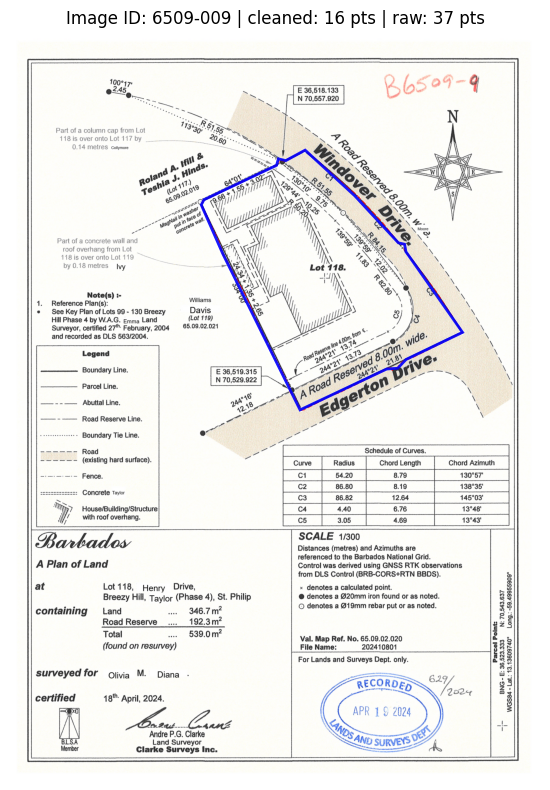

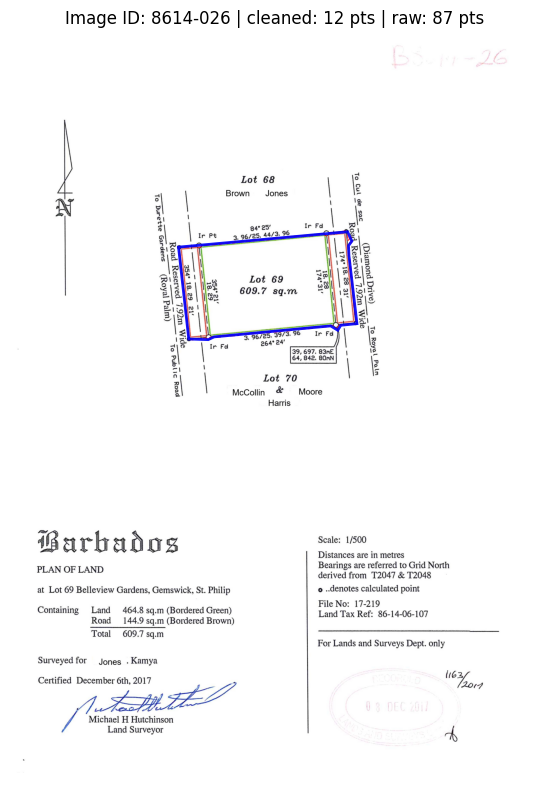

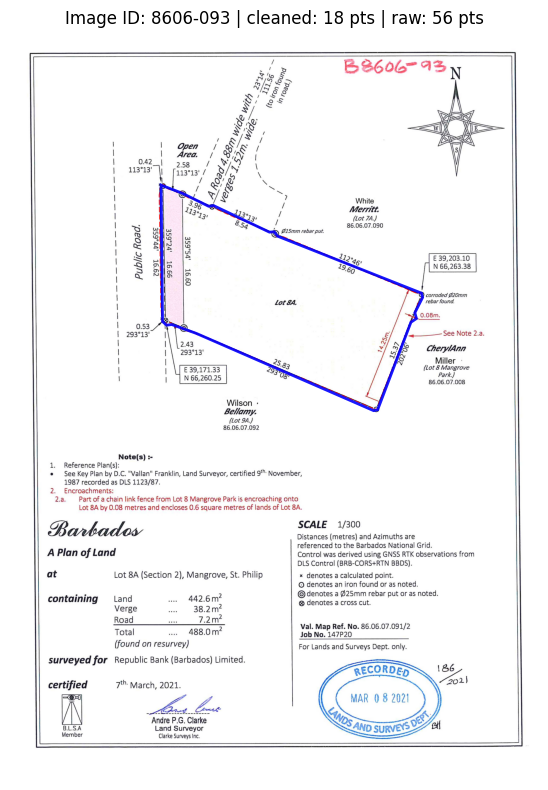

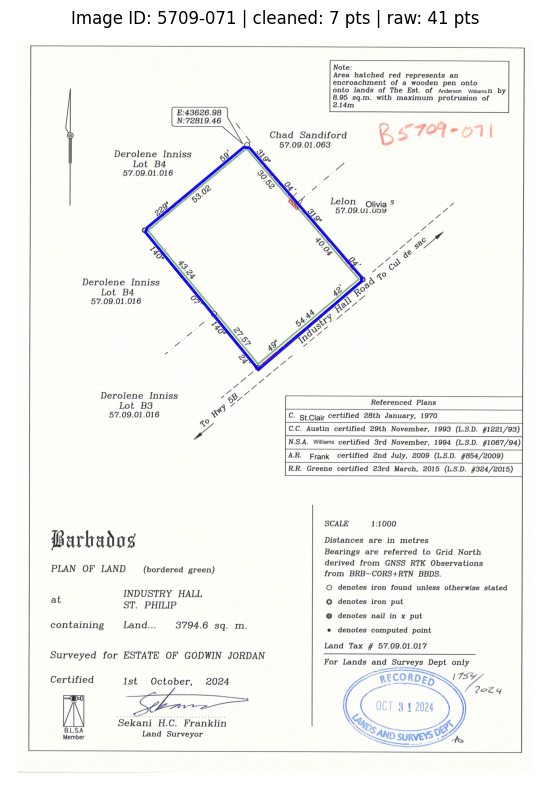

In [ ]:
class CFG:
    OUT_DIR: str = "/kaggle/working"
    ENCODER: str = "efficientnet-b7"
    INFERENCE_THR: float = 0.3
    FULL_SIZE_TRAIN: int = 1024
    ckpt_full = "/kaggle/input/segtest/checkpoints/enhanced_boundary-best.ckpt" # Path to best Model

CFG = CFG()

# POLYGON CLEANING CONFIG

@dataclass
class CleanConfig:
    # Fractions are relative to the max(image_width, image_height)
    spike_frac: float = 0.006        # morphological radius to shave spikes/close dents (0.006)
    simplify_frac: float = 0.0025    # RDP tolerance to eliminate small wiggles (0.0025)
    min_hole_area_ratio: float = 0.003  # drop holes smaller than 0.3% of polygon area (0.003)
    angle_tol_deg: float = 4.0       # remove vertices that are ~collinear within this angle (4.0)
    smooth_straight_deg: float = 165 # if interior angle > this, nudge vertex to average (165)
    max_smooth_shift_frac: float = 0.003  # cap smoothing shift (as image fraction) (0.003)

# GEOMETRY HELPERS

def _ensure_ring(coords: Sequence[Tuple[float, float]]) -> List[Tuple[float, float]]:
    if not coords:
        return []
    return list(coords if coords[0] == coords[-1] else list(coords) + [coords[0]])

def _angle_degrees(p_prev, p, p_next) -> float:
    """Interior angle at p (0..180)."""
    ax, ay = p_prev[0] - p[0], p_prev[1] - p[1]
    bx, by = p_next[0] - p[0], p_next[1] - p[1]
    la = math.hypot(ax, ay)
    lb = math.hypot(bx, by)
    if la == 0 or lb == 0:
        return 180.0
    cosang = max(-1.0, min(1.0, (ax*bx + ay*by) / (la*lb)))
    return math.degrees(math.acos(cosang))

def _remove_almost_collinear(points: List[Tuple[float, float]], angle_tol_deg: float) -> List[Tuple[float, float]]:
    """Drop vertices whose interior angle is ~180° (straight line) within tolerance."""
    if len(points) <= 3:
        return points
    closed = _ensure_ring(points)
    keep = [closed[0]]
    for i in range(1, len(closed)-1):
        ang = _angle_degrees(closed[i-1], closed[i], closed[i+1])
        if abs(180.0 - ang) > angle_tol_deg:  # keep real corners / gentle curves
            keep.append(closed[i])
    keep.append(keep[0])  # close again
    return keep[:-1]

def _smooth_along_straight(points: List[Tuple[float, float]],
                           straight_deg: float,
                           max_shift_px: float) -> List[Tuple[float, float]]:
    """One pass: gently nudge near-collinear vertices toward neighbor average; keep corners."""
    if len(points) <= 3:
        return points
    closed = _ensure_ring(points)
    out = [closed[0]]
    for i in range(1, len(closed)-1):
        p0, p1, p2 = closed[i-1], closed[i], closed[i+1]
        ang = _angle_degrees(p0, p1, p2)
        if ang >= straight_deg:  # almost straight; nudge
            # weighted average (keeps shape stable)
            nx = (0.25*p0[0] + 0.5*p1[0] + 0.25*p2[0])
            ny = (0.25*p0[1] + 0.5*p1[1] + 0.25*p2[1])
            dx, dy = nx - p1[0], ny - p1[1]
            dist = math.hypot(dx, dy)
            if dist > max_shift_px and dist > 0:
                scale = max_shift_px / dist
                nx, ny = (p1[0] + dx*scale, p1[1] + dy*scale)
            out.append((nx, ny))
        else:
            out.append(p1)  # sharp corner; preserve
    out.append(out[0])
    return out[:-1]

# POLYGON CLEANING FUNCTION

def clean_polygon(coords: Optional[Sequence[Tuple[float, float]]],
                  img_shape: Tuple[int, int],
                  cfg: CleanConfig = CleanConfig()) -> Optional[List[Tuple[float, float]]]:
    """
    Fix self-intersections/spikes, drop tiny holes, and smooth small bumps.
    Returns exterior ring as list[(x, y)] (no duplicate closing point).
    """
    if not coords or len(coords) < 3:
        return coords if coords else None

    try:
        from shapely.geometry import Polygon, LineString
        from shapely.ops import polygonize, unary_union
    except ImportError as e:
        raise ImportError("This function requires shapely. Install with `pip install shapely`.") from e

    H, W = img_shape[:2]
    scale = float(max(H, W))
    spike_px = max(1.0, cfg.spike_frac * scale)
    simplify_eps = max(0.5, cfg.simplify_frac * scale)
    max_shift_px = max(0.5, cfg.max_smooth_shift_frac * scale)

    # 1) Cut at self-intersections and polygonize
    ring = _ensure_ring([(float(x), float(y)) for x, y in coords])
    ls = LineString(ring)
    merged = unary_union(ls)                    # splits at intersections
    pieces = list(polygonize(merged))
    if not pieces:
        pieces = [Polygon(ring)]
    # Keep the largest polygon (outer boundary)
    poly = max(pieces, key=lambda p: p.area).buffer(0)  # buffer(0) cures small invalidities

    # 2) Remove small holes
    if poly.area > 0 and poly.interiors:
        keep_holes = []
        cutoff = poly.area * cfg.min_hole_area_ratio
        for interior in poly.interiors:
            if Polygon(interior).area >= cutoff:
                keep_holes.append(interior)
        poly = Polygon(poly.exterior.coords, keep_holes)

    # 3) Shave narrow spikes / close shallow dents (morphological open/close)
    poly = poly.buffer(spike_px).buffer(-spike_px)

    # 4) Simplify to remove tiny wiggles but preserve topology
    poly = poly.simplify(simplify_eps, preserve_topology=True)

    # 5) Convert to list and do vertex-level straightening/smoothing
    pts = list(poly.exterior.coords)[:-1]  # drop closing duplicate
    pts = _remove_almost_collinear(pts, cfg.angle_tol_deg)
    pts = _smooth_along_straight(pts, cfg.smooth_straight_deg, max_shift_px)

    return [(float(x), float(y)) for x, y in pts]

# MODEL AND INFERENCE FUNCTIONS

def build_model():
    """Build model for inference"""
    return smp.UnetPlusPlus(
        encoder_name=CFG.ENCODER,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        decoder_attention_type="scse",
        decoder_channels=(512, 256, 128, 64, 32),
        decoder_use_batchnorm=True,
    )

class LitSeg(pl.LightningModule):
    """Minimal Lightning module for loading checkpoint"""
    def __init__(self):
        super().__init__()
        self.model = build_model()

def get_inference_aug(size):
    """Get preprocessing transforms for inference"""
    ENCODER = CFG.ENCODER
    PREPROC = smp.encoders.get_preprocessing_params(ENCODER, pretrained="imagenet")
    IM_MEAN, IM_STD = PREPROC["mean"], PREPROC["std"]

    ops = []
    if size:
        ops.append(A.Resize(size, size, interpolation=cv2.INTER_LINEAR))
    ops += [A.Normalize(mean=IM_MEAN, std=IM_STD), ToTensorV2()]
    return A.Compose(ops)

def infer_image_and_get_short_polygon(image_path, model, device, size, epsilon_factor=0.001):
    """
    Performs inference on a single image, finds the largest polygon,
    approximates it, and returns the shortened coordinates.

    Args:
        image_path (str): Path to the input image.
        model (torch.nn.Module): Trained segmentation model.
        device (torch.device): Device to run inference on (cuda or cpu).
        size (int): The size the image was resized to during training.
        epsilon_factor (float): Factor for epsilon in cv2.approxPolyDP.

    Returns:
        tuple: (shortened_coordinates, original_image) where shortened_coordinates
               is a list of (x, y) tuples or None if no polygon found.
    """
    # Load and preprocess image
    img_orig = cv2.imread(image_path, cv2.IMREAD_COLOR)[:, :, ::-1]
    original_height, original_width = img_orig.shape[:2]

    # Apply preprocessing
    inference_aug = get_inference_aug(size)
    augmented = inference_aug(image=img_orig)
    img_processed = augmented["image"].unsqueeze(0).to(device)

    # Run inference
    with torch.no_grad():
        logits = model(img_processed)
        prob = torch.sigmoid(logits).squeeze(0).cpu()
        pred_mask = (prob > CFG.INFERENCE_THR).float()

    # Resize predicted mask to original image size
    pred_mask_resized = cv2.resize(
        pred_mask.squeeze(0).cpu().numpy().astype(np.uint8),
        (original_width, original_height),
        interpolation=cv2.INTER_NEAREST
    )

    # Find contours in the resized predicted mask
    contours, _ = cv2.findContours(pred_mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the largest contour and convert to shortened polygon
    shortened_coordinates = None
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        # Ensure the contour has at least 3 points to form a polygon
        if len(largest_contour) >= 3:
            # Approximate the polygon
            epsilon = epsilon_factor * cv2.arcLength(largest_contour, True)
            approx_polygon_np = cv2.approxPolyDP(largest_contour, epsilon, True)
            shortened_coordinates = [tuple(point[0]) for point in approx_polygon_np]

    return shortened_coordinates, img_orig

# MAIN INFERENCE AND PROCESSING FUNCTION

def run_inference_with_cleaning(plot_limit=4, extract_path=None):
    """Main function to run inference on all test images with polygon cleaning"""
    # Setup paths
    if extract_path is None:
        # Try to use EXTRACT_PATH if it exists in global scope, otherwise use default
        try:
            test_images_dir = Path(EXTRACT_PATH) / "test"
        except NameError:
            test_images_dir = Path("./test")  # fallback default
    else:
        test_images_dir = Path(extract_path) / "test"

    output_csv_path = "/kaggle/working/test_predictions.csv"

    # Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lit_model_full = LitSeg.load_from_checkpoint(CFG.ckpt_full)
    model_full = lit_model_full.model.to(device)
    model_full.eval()

    # Get test image files
    image_files = [f for f in os.listdir(test_images_dir)
                   if f.endswith(('.jpg', '.jpeg', '.png', '.tif'))]

    print(f"Running inference on {len(image_files)} test images...")

    # Store results
    results = []
    plot_examples = []  # For visualization

    # Process each image
    for image_file in tqdm(image_files):
        image_id = Path(image_file).stem.replace("anonymised_", "")
        image_path = str(test_images_dir / image_file)

        # Perform inference
        shortened_polygon_coords, original_image = infer_image_and_get_short_polygon(
            image_path, model_full, device, CFG.FULL_SIZE_TRAIN
        )

        # Clean and smooth the polygon
        if shortened_polygon_coords:
            H, W = original_image.shape[:2]
            fixed_coords = clean_polygon(shortened_polygon_coords, (H, W))
        else:
            fixed_coords = None

        # Format coordinates for CSV
        coords_str = str(fixed_coords) if fixed_coords else "None"
        results.append({"ID": image_id, "Predicted_Polygon": coords_str})

        # Store examples for plotting
        if len(plot_examples) < plot_limit:
            plot_examples.append({
                "ID": image_id,
                "image": original_image,
                "polygon_raw": shortened_polygon_coords,
                "polygon": fixed_coords
            })

    # Save results
    predictions_df = pd.DataFrame(results)
    predictions_df.to_csv(output_csv_path, index=False)

    print(f"\nPredictions saved to: {output_csv_path}")
    print(f"Total images processed: {len(results)}")

    # Display first few results
    display(predictions_df.head())

    print(f"\nPlotting {len(plot_examples)} cleaned examples:")
    for ex in plot_examples:
        img = ex["image"]
        poly = ex["polygon"]
        poly_raw = ex["polygon_raw"]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img)

        # Show raw (thin, dashed) vs cleaned (thicker, solid) for comparison
        if poly_raw:
            try:
                ax.add_patch(MplPolygon(poly_raw, fill=False, linewidth=1,
                                      linestyle="--", edgecolor='red', alpha=0.7))
            except Exception:
                pass

        if poly:
            ax.add_patch(MplPolygon(poly, fill=False, linewidth=2,
                                  edgecolor='blue', alpha=0.9))

        title = f"Image ID: {ex['ID']}"
        if poly:
            title += f" | cleaned: {len(poly)} pts"
        if poly_raw:
            title += f" | raw: {len(poly_raw)} pts"
        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return predictions_df, plot_examples

predictions_df_b7, examples = run_inference_with_cleaning()